<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v2/blob/master/Student_MobileNetV3_Pretrained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07 · Student Candidate — MobileNetV3-Small (pretrained ImageNet)

MobileNetV3-Small fine-tuned from ImageNet weights.
**This is the selected student for knowledge distillation.**

**Justification for selection over MobileNetV2-scratch:**
- Hardware-Aware NAS: designed explicitly for mobile/edge inference latency
- SE (Squeeze-and-Excitation) blocks: channel attention improves accuracy/param ratio
- h-swish activations: more efficient than ReLU6 on hardware with lookup tables
- Pretrained weights: better feature initialization on only 7,000 images
- ~2.5M parameters: suitable for STM32 deployment after INT8 quantization

**Two-phase protocol:**
- Phase 1 (epochs 1–9):  backbone frozen, classifier head only at lr=3e-4
- Phase 2 (epochs 10–25): full unfreeze at lr=1e-4


In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/thesis/utils/")


Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Standard imports ────────────────────────────────────────────────
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders, get_test_loader
from utils.models  import (
    VGG_Scratch, VGG_Pretrained,
    ResNet_Scratch, ResNet18_Pretrained,
    MobileNetV2_Scratch, MobileNetV3_Pretrained,
    count_params, model_size_mb, MODEL_REGISTRY,
)
from utils.train import (
    setup_device, set_seed, evaluate,
    train_model, train_model_three_phase,
    train_multi_seed, train_kd, plot_history,
)

device = setup_device(seed=41)


Device: cpu


In [3]:
# ── Dataset setup ───────────────────────────────────────────────────
prepare_dataset()


1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests


PosixPath('/content/vww_work/extracted/vw_coco2014_96')

## Standardized hyperparameters

All models use identical settings to ensure fair comparison:

| Parameter | Scratch models | Pretrained models |
|-----------|---------------|-------------------|
| Batch size | 64 | 64 |
| Optimizer | Adam | Adam |
| Weight decay | 1e-4 | 1e-4 |
| Label smoothing | 0.1 | 0.1 |
| Augmentation | standard | standard |
| Scheduler | CosineAnnealingLR | CosineAnnealingLR |
| Patience | 10 | 10 |
| Seeds | [41, 52, 63] | [41, 52, 63] |
| Max epochs | 50 | 30 |
| LR | 1e-3 | 3e-4 → 1e-4 → 3e-5 (3-phase) |

Pretrained models use fewer max epochs because transfer learning converges faster.
The three-phase progressive unfreeze is only applicable to pretrained models.


In [4]:
SAVE_DIR = "/content/drive/My Drive/Colab Notebooks"


In [5]:
train_loader, val_loader = get_loaders(batch_size=64, augmentation="standard")


Train: 7000 | Val: 1500 | Batch: 64


In [6]:
# MobileNetV3 uses two-phase (not three) — backbone is lighter, full unfreeze is safe at ep 10
results, best = train_multi_seed(
    model_fn     = MobileNetV3_Pretrained,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    seeds        = [41, 52, 63],
    save_dir     = SAVE_DIR,
    name_prefix  = "mobilenetv3_baseline",
    pretrained   = True,
    epochs          = 25,
    lr_phase1       = 3e-4,
    lr_phase2       = 1e-4,
    lr_phase3       = 1e-4,   # phase3 same as phase2 (effectively two-phase)
    phase2_epoch    = 10,
    phase3_epoch    = 999,    # disable phase3 transition
    weight_decay    = 1e-4,
    label_smoothing = 0.1,
    patience        = 10,
)



Seed 41
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 71.2MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[P1] Epoch   1/25 | LR 0.000291 | Train 66.81% | Val 74.93% ✅
[P1] Epoch   2/25 | LR 0.000265 | Train 71.49% | Val 74.73%
[P1] Epoch   3/25 | LR 0.000225 | Train 72.34% | Val 75.73% ✅
[P1] Epoch   4/25 | LR 0.000176 | Train 73.34% | Val 76.00% ✅
[P1] Epoch   5/25 | LR 0.000124 | Train 74.10% | Val 75.27%
[P1] Epoch   6/25 | LR 0.000075 | Train 75.14% | Val 74.87%
[P1] Epoch   7/25 | LR 0.000035 | Train 74.80% | Val 75.87%
[P1] Epoch   8/25 | LR 0.000009 | Train 75.86% | Val 75.87%
[P1] Epoch   9/25 | LR 0.000000 | Train 75.56% | Val 75.73%

── Phase 2: partial unfreeze (epoch 10) ──
[P2] Epoch  10/25 | LR 0.000100 | Train 75.40% | Val 75.40%
[P2] Epoch  11/25 | LR 0.000100 | Train 75.06% | Val 75.20%
[P2] Epoch  12/25 | LR 0.000100 | Train 75.53% | Val 76.33% ✅
[P2] Epoch  13/25 | LR 0.000100 | Train 76.29% | Val 75.47%
[P2] Epoch  14/25 | LR 0.000100 | Train 75.46% | Val 75.80%
[P2] Epoch  15/25 | LR 0.000100 | Train 75.90% | Val 75.13%
[P2] Epoch  16/25 | LR 0.000100 | Train 76.39% |

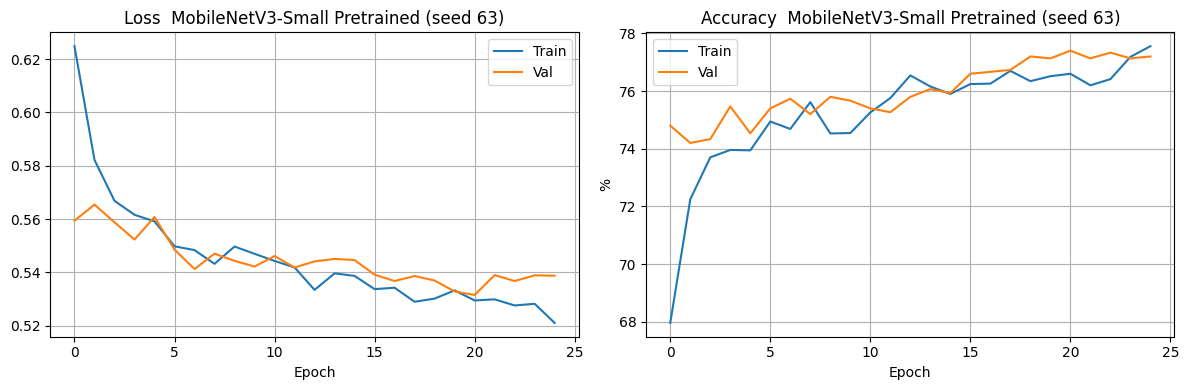

Best: 77.40% @ epoch 21  (14.6 min)

MobileNetV3-Small  |  Mean: 77.16% ± 0.19%
Best: 77.40% (seed 63)
Checkpoint: /content/drive/My Drive/Colab Notebooks/mobilenetv3_baseline_seed_63.pth


In [7]:
plot_history(best, title=f"MobileNetV3-Small Pretrained (seed {best['seed']})")

accs = [r["best_acc"] for r in results]
print(f"\nMobileNetV3-Small  |  Mean: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")
print(f"Best: {best['best_acc']*100:.2f}% (seed {best['seed']})")
print(f"Checkpoint: {best['save_path']}")
